# Graph Neural Networks — TensorFlow Pipeline

PyTorch side (`PyTorch/18-gnn/pipeline.ipynb`) ran four variants on two datasets. TF side covers the **two from-scratch variants (V1 GCN, V3 GAT)** on the same two datasets for framework parity. V2 GraphSAGE and V4 GIN are PyTorch-only — their lever is scale-specific machinery (`NeighborLoader`, `GINConv`) where Spektral lacks mature equivalents and TF-GNN's `GraphTensor` API adds heavy ceremony.

## Why from-scratch primitives on TF (not Spektral)

Smoke test revealed **Spektral 1.3.1 is broken on Keras 3** (ships with TF 2.21). `GCNConv.call()` does `output *= mask[0]` assuming Keras 2's `mask=None`; Keras 3 passes `[None, None]` and the multiplication fails with a NoneType conversion error. Spektral hasn't been updated for Keras 3 (last release Dec 2023).

Pivot: implement V1 GCN and V3 GAT directly from TF primitives. Phase 0 verified `tf.sparse.sparse_dense_matmul`, `tf.math.unsorted_segment_max/sum`, and Keras `Dense` all work on WSL2 TF 2.21 GPU. This aligns with the approved plan intent (V1/V3 from scratch in both frameworks anyway) and delivers the same educational value as PyTorch's from-scratch GCN/GAT.

## Variants + Expected Results

| # | Model | Datasets | From-scratch? | PT Result (reference) |
|---|-------|----------|---------------|------------------------|
| V1 | GCN | Cora + ogbn-arxiv | Yes (tf.sparse + Dense) | Cora 0.8140, arxiv OGB 0.6985 |
| V3 | GAT | Cora + ogbn-arxiv | Yes (segment_softmax + Dense) | Cora 0.8310, arxiv OGB 0.7025 |

**Framework parity target**: TF variants within 2pp of PT counterparts on each dataset. Minor deviation expected from different random init seeds (even with RANDOM_STATE=113, TF and PT tensor initializers differ slightly) and optimizer implementation details.

## Datasets

Reused from PyTorch preprocessing — same `data/processed/gnn/` cache, same `CORA_TRANSFORM` + `ARXIV_TRANSFORM`. No redundant downloads. The PyG Planetoid and OGB dataset objects load in this notebook too; we convert to TF tensors at setup time.

| Dataset | Nodes | Edges | Features | Classes | Split |
|---------|-------|-------|----------|---------|-------|
| Cora | 2,708 | 10,556 | 1,433 BoW | 7 | Kipf transductive (140/500/1000) |
| ogbn-arxiv | 169,343 | 2,315,598 (symmetrized) | 128 word2vec | 40 | Temporal (train <=2017, val 2018, test 2019+) |

## Pipeline Steps

1. Setup — load data, convert to TF tensors, precompute sparse A_hat
2. GCN layer + model (from scratch: `tf.sparse.sparse_dense_matmul` + Dense)
3. V1 GCN on Cora (2-layer, 200 epochs, full-batch)
4. V1 GCN on ogbn-arxiv (3-layer, 500 epochs)
5. GAT layer + model (from scratch: segment softmax + Dense)
6. V3 GAT on Cora (8 heads x 8 features, Velickovic recipe)
7. V3 GAT on ogbn-arxiv (2 heads x 128 features, scaled)
8. Cross-variant comparison + cross-framework parity check vs PyTorch

In [1]:
# Step 1: Setup + Data Loading (from PyG/OGB cache, converted to TF tensors)

# Standard lib
import os
import sys
import json

# Suppress TF's verbose CUDA registration spam (before `import tensorflow`)
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "1"

# Scientific / plotting
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# TensorFlow
import tensorflow as tf

# Torch / PyG just for data loading (read-only; CPU is fine since TF handles compute)
import torch
from torch_geometric.datasets import Planetoid
from ogb.nodeproppred import PygNodePropPredDataset, Evaluator

# Force torch to CPU mode for loading -- TF owns the GPU during training
torch.set_default_device('cpu')

# Project root -- Jupyter kernel cwd in WSL2 is the project root itself,
# so Path('../..') resolves one level too high. Hardcode absolute path
BASE_DIR = '/mnt/c/Users/Max/Desktop/Coding/.Projects/2026/ml-framework-comparisons'
sys.path.insert(0, BASE_DIR)
sys.path.insert(0, os.path.join(BASE_DIR, 'data-preperation'))

# Metrics: evaluate_classifier returns {accuracy, macro_f1, ...} from raw (N,) labels
from utils.metrics import evaluate_classifier, print_metrics

# Performance: context manager (gpu=True works for TF per utility's auto-detection)
from utils.performance import track_performance, track_inference

# Results persistence (cross-framework JSONs for PT + TF side-by-side comparison)
from utils.results import build_results_dict, add_result, print_comparison

# Viz: raw (y_true, y_pred) label-consuming plot utilities
from utils.visualization import (
    plot_confusion_matrix_multiclass,
    plot_per_class_f1,
)

# Canonical transforms (single source of truth across PT + TF pipelines)
from preprocess_gnn import CORA_TRANSFORM, ARXIV_TRANSFORM

# Reproducibility
RANDOM_STATE = 113
tf.random.set_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)   # affects PyG loaders for determinism

# Device
gpus = tf.config.list_physical_devices('GPU')
print(f"TF: {tf.__version__}, GPUs visible: {gpus}")
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    DEVICE = '/GPU:0'
else:
    DEVICE = '/CPU:0'

DATA_ROOT = os.path.join(BASE_DIR, 'data', 'processed', 'gnn')
print(f"Data root: {DATA_ROOT}")

CORA_CLASS_NAMES = [
    'Case_Based', 'Genetic_Algorithms', 'Neural_Networks',
    'Probabilistic_Methods', 'Reinforcement_Learning', 'Rule_Learning', 'Theory',
]


def pyg_to_tf(pyg_data):
    """
    Convert a torch_geometric Data object (CPU torch tensors) to a dict of
    TF tensors. Keeps names aligned with PT usage (.x, .edge_index, .y, masks).
    """
    out = {
        'x':          tf.convert_to_tensor(pyg_data.x.numpy(), dtype=tf.float32),
        'edge_index': tf.convert_to_tensor(pyg_data.edge_index.numpy(), dtype=tf.int64),
        'y':          tf.convert_to_tensor(pyg_data.y.view(-1).numpy(), dtype=tf.int64),
        'num_nodes':  pyg_data.num_nodes,
        'num_features': pyg_data.num_features,
    }
    for mask_name in ('train_mask', 'val_mask', 'test_mask'):
        if hasattr(pyg_data, mask_name) and getattr(pyg_data, mask_name) is not None:
            out[mask_name] = tf.convert_to_tensor(
                getattr(pyg_data, mask_name).numpy(), dtype=tf.bool,
            )
    return out


# Load Cora (transductive benchmark, small graph)
cora_pyg = Planetoid(root=DATA_ROOT, name='Cora', transform=CORA_TRANSFORM)[0]
cora = pyg_to_tf(cora_pyg)

# Load ogbn-arxiv (OGB leaderboard benchmark)
arxiv_dataset = PygNodePropPredDataset(
    name='ogbn-arxiv', root=DATA_ROOT, transform=ARXIV_TRANSFORM,
)
arxiv_pyg = arxiv_dataset[0]
arxiv = pyg_to_tf(arxiv_pyg)
arxiv_split_pyg = arxiv_dataset.get_idx_split()
arxiv_split = {
    k: tf.convert_to_tensor(v.numpy(), dtype=tf.int64)
    for k, v in arxiv_split_pyg.items()
}

arxiv_evaluator = Evaluator(name='ogbn-arxiv')

print("=" * 60)
print("GNN - TensorFlow Pipeline Setup Complete")
print("=" * 60)
print(f"\nCora:")
print(f"    x shape:          {tuple(cora['x'].shape)}  dtype: {cora['x'].dtype.name}")
print(f"    edge_index shape: {tuple(cora['edge_index'].shape)}")
print(f"    classes:          {int(tf.reduce_max(cora['y'])) + 1}")
print(f"    masks train/val/test: "
      f"{int(tf.reduce_sum(tf.cast(cora['train_mask'], tf.int32)))}/"
      f"{int(tf.reduce_sum(tf.cast(cora['val_mask'], tf.int32)))}/"
      f"{int(tf.reduce_sum(tf.cast(cora['test_mask'], tf.int32)))}")

print(f"\nogbn-arxiv:")
print(f"    x shape:          {tuple(arxiv['x'].shape)}  dtype: {arxiv['x'].dtype.name}")
print(f"    edge_index shape: {tuple(arxiv['edge_index'].shape)}  (symmetrized)")
print(f"    classes:          {int(tf.reduce_max(arxiv['y'])) + 1}")
print(f"    splits train/valid/test: "
      f"{len(arxiv_split['train']):,}/"
      f"{len(arxiv_split['valid']):,}/"
      f"{len(arxiv_split['test']):,}")
print(f"    OGB evaluator metric: {arxiv_evaluator.eval_metric}")

I0000 00:00:1776738414.522460    2254 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1776738415.620378    2254 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
/home/max/tf-gpu-venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


TF: 2.21.0, GPUs visible: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Data root: /mnt/c/Users/Max/Desktop/Coding/.Projects/2026/ml-framework-comparisons/data/processed/gnn


/home/max/tf-gpu-venv/lib/python3.12/site-packages/ogb/nodeproppred/dataset_pyg.py:69: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  self.data, self.slices = torch.load(self

GNN - TensorFlow Pipeline Setup Complete

Cora:
    x shape:          (2708, 1433)  dtype: float32
    edge_index shape: (2, 10556)
    classes:          7
    masks train/val/test: 140/500/1000

ogbn-arxiv:
    x shape:          (169343, 128)  dtype: float32
    edge_index shape: (2, 2315598)  (symmetrized)
    classes:          40
    splits train/valid/test: 90,941/29,799/48,603
    OGB evaluator metric: acc


/home/max/tf-gpu-venv/lib/python3.12/site-packages/ogb/nodeproppred/dataset_pyg.py:91: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at ../torch/csrc/utils/tensor_numpy.cpp:206.)
  train_idx = torch.from_numpy(pd.read_csv(osp.join(path, 'train.csv.gz'), compression='gzip', header = None).values.T[0]).to(torch.long)


In [2]:
# Step 2: GCN Layer + Model (TF from scratch, no Spektral)

"""
TF-native GCN matching our PyTorch GCN exactly:

    H' = sigma(A_hat @ H @ W)

where A_hat = D^(-1/2) (A + I) D^(-1/2) is precomputed once per graph
as a tf.sparse.SparseTensor and reused across every forward pass.

Primitives only:
    tf.sparse.SparseTensor + tf.sparse.sparse_dense_matmul
    tf.keras.layers.Dense
    tf.nn.dropout + tf.nn.relu
"""


def normalize_adj_symmetric_tf(edge_index, num_nodes):
    """
    Compute symmetric-normalized adjacency as a tf.sparse.SparseTensor:
        A_hat = D^(-1/2) (A + I) D^(-1/2)

    Args:
        edge_index: tf.Tensor of shape (2, E), int64. Should NOT contain self-loops
            (they are added here).
        num_nodes: int, total node count N.

    Returns:
        tf.sparse.SparseTensor of shape (N, N), reorder()'d into row-major.
    """
    # Add self-loops: append (i, i) for every node i
    self_loops = tf.stack([tf.range(num_nodes, dtype=tf.int64)] * 2)
    edge_index_sl = tf.concat([edge_index, self_loops], axis=1)

    src, dst = edge_index_sl[0], edge_index_sl[1]

    # Degree per source node (symmetric with dst since graph is undirected)
    deg = tf.math.bincount(
        tf.cast(src, tf.int32), minlength=num_nodes, dtype=tf.float32,
    )
    deg_inv_sqrt = tf.math.rsqrt(deg)
    # Guard against inf for any isolated nodes (shouldn't happen with self-loops)
    deg_inv_sqrt = tf.where(
        tf.math.is_inf(deg_inv_sqrt), tf.zeros_like(deg_inv_sqrt), deg_inv_sqrt,
    )

    # Per-edge weight: D^(-1/2)[src] * D^(-1/2)[dst]
    edge_weight = tf.gather(deg_inv_sqrt, src) * tf.gather(deg_inv_sqrt, dst)

    # tf.sparse expects indices shaped (nnz, 2)
    indices = tf.stack([src, dst], axis=1)
    sparse_adj = tf.sparse.SparseTensor(
        indices=indices, values=edge_weight,
        dense_shape=[num_nodes, num_nodes],
    )
    # TF requires row-major index order for sparse_dense_matmul correctness
    return tf.sparse.reorder(sparse_adj)


class GCNLayer(tf.keras.layers.Layer):
    """
    Single GCN layer: linear projection then symmetric-normalized neighbor
    aggregation via sparse matmul.

    Call signature: layer(x, A_hat) -> (N, out_features)
    """

    def __init__(self, out_features, **kwargs):
        super().__init__(**kwargs)
        self.dense = tf.keras.layers.Dense(out_features, use_bias=True)

    def call(self, x, A_hat):
        return tf.sparse.sparse_dense_matmul(A_hat, self.dense(x))


class GCN(tf.keras.Model):
    """
    Generic multi-layer GCN matching our PyTorch GCN class.

    Architecture (num_layers=L):
        input -> hidden -> hidden -> ... -> num_classes
                  |                   |
                 L-1 intermediate   final (logits, no activation)

    Dropout BEFORE every layer (including input) -- Kipf recipe.
    ReLU between layers; raw logits at the end.
    """

    def __init__(self, hidden, num_classes, num_layers=2, dropout=0.5, **kwargs):
        super().__init__(**kwargs)
        assert num_layers >= 2, "GCN needs at least 2 layers"
        self.dropout_rate = dropout

        dims_out = [hidden] * (num_layers - 1) + [num_classes]
        self.gcn_layers = [GCNLayer(d) for d in dims_out]

    def call(self, x, A_hat, training=False):
        for i, layer in enumerate(self.gcn_layers):
            if training and self.dropout_rate > 0:
                x = tf.nn.dropout(x, rate=self.dropout_rate)
            x = layer(x, A_hat)
            if i < len(self.gcn_layers) - 1:
                x = tf.nn.relu(x)
        return x



# Sanity test on Cora (matches PT Cell 2 shape/param counts for parity)
with tf.device(DEVICE):
    _test_A_hat = normalize_adj_symmetric_tf(cora['edge_index'], cora['num_nodes'])
    _test_model = GCN(
        hidden=16,
        num_classes=int(tf.reduce_max(cora['y'])) + 1,
        num_layers=2,
        dropout=0.5,
    )
    # Build the model (Keras defers weight allocation until first call)
    _test_logits = _test_model(cora['x'], _test_A_hat, training=False)

print(f"GCN sanity test on Cora:")
print(f"    Input x:      {tuple(cora['x'].shape)}  {cora['x'].dtype.name}")
print(f"    A_hat sparse: {tuple(_test_A_hat.dense_shape.numpy())}  "
      f"({int(_test_A_hat.values.shape[0]):,} nnz)")
print(f"    Output logits: {tuple(_test_logits.shape)}  {_test_logits.dtype.name}")
print(f"    Total params: {_test_model.count_params():,}")

# Cleanup scratch (TF doesn't have an explicit equivalent to torch.cuda.empty_cache,
# but releasing references lets Python GC reclaim eventually)
del _test_A_hat, _test_model, _test_logits

GCN sanity test on Cora:
    Input x:      (2708, 1433)  float32
    A_hat sparse: (np.int64(2708), np.int64(2708))  (13,264 nnz)
    Output logits: (2708, 7)  float32
    Total params: 23,063


A_hat (Cora): (np.int64(2708), np.int64(2708)), nnz=13,264
Model: 2-layer GCN (1433 -> 16 -> 7), 23,063 params

Training V1 GCN on Cora (200 epochs)...
    ep   1: train_loss=1.9468, val_loss=1.9475, val_acc=0.1620
    ep  20: train_loss=1.7482, val_loss=1.8290, val_acc=0.3940
    ep  40: train_loss=1.3328, val_loss=1.5597, val_acc=0.7020
    ep  60: train_loss=0.9074, val_loss=1.2252, val_acc=0.7660
    ep  80: train_loss=0.5504, val_loss=0.9551, val_acc=0.7780
    ep 100: train_loss=0.3377, val_loss=0.8078, val_acc=0.7840
    ep 120: train_loss=0.2440, val_loss=0.7379, val_acc=0.7860
    ep 140: train_loss=0.1666, val_loss=0.7228, val_acc=0.7760
    ep 160: train_loss=0.1600, val_loss=0.7052, val_acc=0.7840
    ep 180: train_loss=0.1331, val_loss=0.7162, val_acc=0.7760
    ep 200: train_loss=0.0761, val_loss=0.7056, val_acc=0.7680

    Train time: 9.92s, peak GPU memory: 231.3 MB
    Best val acc: 0.7860

METRICS — V1 GCN - Cora (TF)
Metric                           Train         Tes

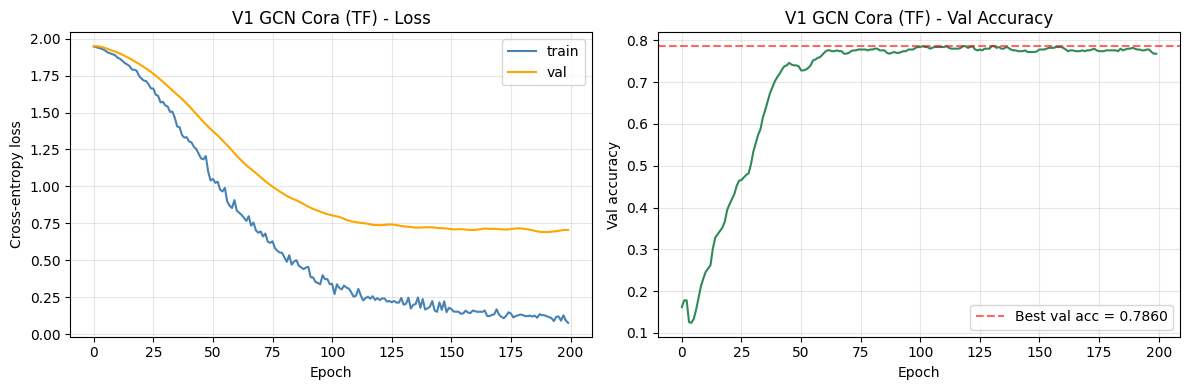

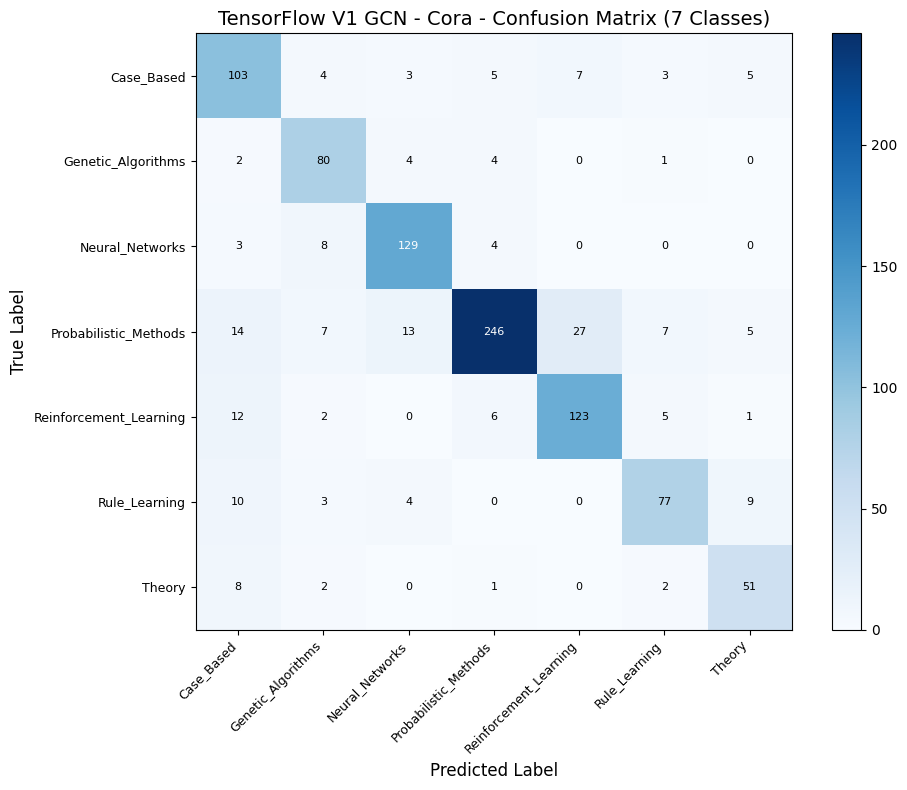

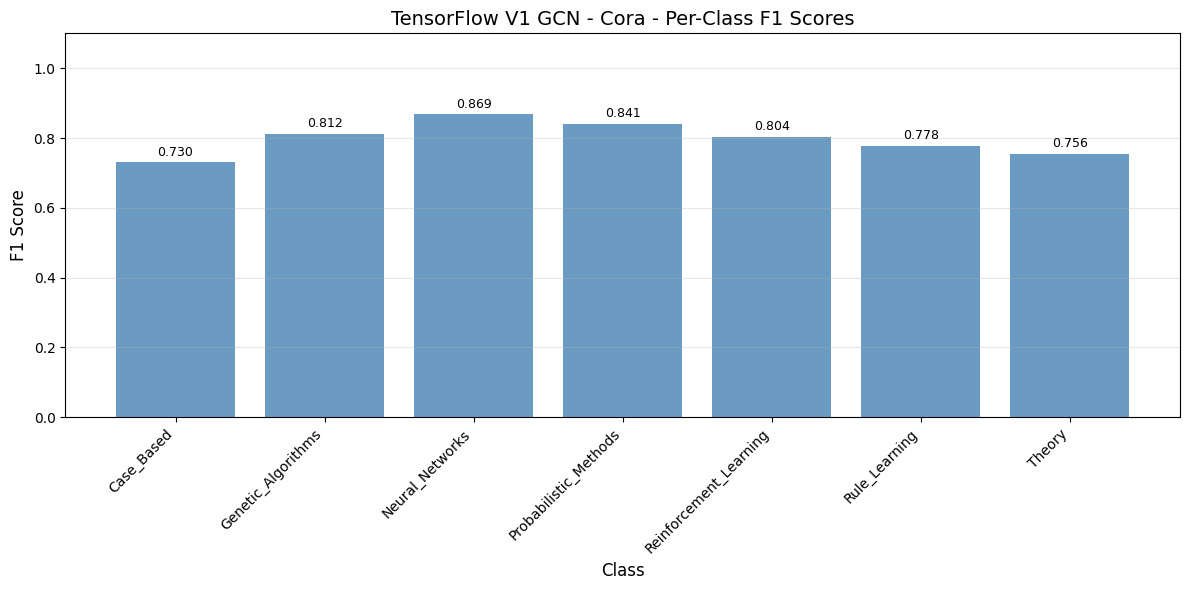


    Checkpoint: /mnt/c/Users/Max/Desktop/Coding/.Projects/2026/ml-framework-comparisons/TensorFlow/18-gnn/results/v1_gcn_cora_best.weights.h5
    Model size: 90.09 KB, params: 23,063


In [3]:
# Step 3: V1 GCN on Cora

"""
Kipf & Welling (2017) recipe on Cora in TF -- matches PT V1 hyperparameters
exactly for fair cross-framework comparison.
"""

# V1 Cora hyperparameters (Kipf 2017 defaults, identical to PT V1)
V1_CORA_HIDDEN = 16
V1_CORA_LAYERS = 2
V1_CORA_DROPOUT = 0.5
V1_CORA_LR = 0.01
V1_CORA_WEIGHT_DECAY = 5e-4
V1_CORA_EPOCHS = 200
V1_CORA_LOG_EVERY = 20

# Results directory for TF pipeline artifacts
RESULTS_DIR = os.path.join(BASE_DIR, 'TensorFlow', '18-gnn', 'results')
os.makedirs(RESULTS_DIR, exist_ok=True)

# In-notebook containers for cross-variant + cross-framework comparison
cora_variants = []      # V1 GCN, V3 GAT on Cora (TF side)
arxiv_variants = []     # V1 GCN, V3 GAT on ogbn-arxiv (TF side)


# Build symmetric-normalized adjacency once (graph constant)
with tf.device(DEVICE):
    A_hat_cora = normalize_adj_symmetric_tf(cora['edge_index'], cora['num_nodes'])
print(f"A_hat (Cora): {tuple(A_hat_cora.dense_shape.numpy())}, "
      f"nnz={int(A_hat_cora.values.shape[0]):,}")


# Instantiate model + optimizer
tf.random.set_seed(RANDOM_STATE)
with tf.device(DEVICE):
    model_v1_cora = GCN(
        hidden=V1_CORA_HIDDEN,
        num_classes=int(tf.reduce_max(cora['y'])) + 1,
        num_layers=V1_CORA_LAYERS,
        dropout=V1_CORA_DROPOUT,
    )
    # Build weights with a dummy forward pass (Keras defers allocation)
    _ = model_v1_cora(cora['x'], A_hat_cora, training=False)

# Keras 3 Adam has decoupled weight_decay (AdamW-style) built in
optimizer = tf.keras.optimizers.Adam(
    learning_rate=V1_CORA_LR,
    weight_decay=V1_CORA_WEIGHT_DECAY,
)
num_params = int(model_v1_cora.count_params())
print(f"Model: 2-layer GCN ({cora['num_features']} -> {V1_CORA_HIDDEN} -> "
      f"{int(tf.reduce_max(cora['y'])) + 1}), {num_params:,} params")


# Training loop -- full-batch, transductive (loss only on train_mask)
history = {'train_loss': [], 'val_loss': [], 'val_acc': []}
best_val_acc = 0.0
best_weights = None

# Manual TF GPU memory tracking
tf.config.experimental.reset_memory_stats('GPU:0') if gpus else None

print(f"\nTraining V1 GCN on Cora ({V1_CORA_EPOCHS} epochs)...")
with track_performance() as perf:
    for epoch in range(V1_CORA_EPOCHS):
        # Train step: forward, compute masked CE loss, backprop
        with tf.GradientTape() as tape:
            logits = model_v1_cora(cora['x'], A_hat_cora, training=True)
            train_logits = tf.boolean_mask(logits, cora['train_mask'])
            train_labels = tf.boolean_mask(cora['y'], cora['train_mask'])
            train_loss = tf.reduce_mean(
                tf.nn.sparse_softmax_cross_entropy_with_logits(
                    labels=train_labels, logits=train_logits,
                )
            )
        grads = tape.gradient(train_loss, model_v1_cora.trainable_variables)
        optimizer.apply_gradients(zip(grads, model_v1_cora.trainable_variables))

        # Eval on val split
        val_logits_full = model_v1_cora(cora['x'], A_hat_cora, training=False)
        val_logits = tf.boolean_mask(val_logits_full, cora['val_mask'])
        val_labels = tf.boolean_mask(cora['y'], cora['val_mask'])
        val_loss = tf.reduce_mean(
            tf.nn.sparse_softmax_cross_entropy_with_logits(
                labels=val_labels, logits=val_logits,
            )
        )
        val_pred = tf.argmax(val_logits, axis=-1, output_type=tf.int64)
        val_acc = float(tf.reduce_mean(tf.cast(val_pred == val_labels, tf.float32)))

        history['train_loss'].append(float(train_loss))
        history['val_loss'].append(float(val_loss))
        history['val_acc'].append(val_acc)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_weights = [w.numpy() for w in model_v1_cora.weights]

        if (epoch + 1) % V1_CORA_LOG_EVERY == 0 or epoch == 0:
            print(f"    ep {epoch + 1:3d}: train_loss={float(train_loss):.4f}, "
                  f"val_loss={float(val_loss):.4f}, val_acc={val_acc:.4f}")

# Peak TF GPU memory captured outside the context manager
peak_gpu_mb = (
    tf.config.experimental.get_memory_info('GPU:0')['peak'] / 1024 / 1024
    if gpus else 0.0
)
print(f"\n    Train time: {perf['time']:.2f}s, peak GPU memory: {peak_gpu_mb:.1f} MB")
print(f"    Best val acc: {best_val_acc:.4f}")


# Restore best-val weights for honest test evaluation
for w, best in zip(model_v1_cora.weights, best_weights):
    w.assign(best)

test_logits_full = model_v1_cora(cora['x'], A_hat_cora, training=False).numpy()
test_mask_np = cora['test_mask'].numpy()
train_mask_np = cora['train_mask'].numpy()
test_true = cora['y'].numpy()[test_mask_np]
train_true = cora['y'].numpy()[train_mask_np]
test_probs = tf.nn.softmax(test_logits_full[test_mask_np], axis=-1).numpy()
test_pred = test_logits_full[test_mask_np].argmax(axis=-1)
train_pred = test_logits_full[train_mask_np].argmax(axis=-1)

test_metrics = evaluate_classifier(test_true, test_pred, test_probs)
train_metrics = evaluate_classifier(train_true, train_pred)
print_metrics(train_metrics, test_metrics, title="V1 GCN - Cora (TF)")


# Inference speed (full-graph forward pass)
def _predict_cora(_):
    return model_v1_cora(cora['x'], A_hat_cora, training=False).numpy().argmax(axis=-1)
inference_stats = track_inference(_predict_cora, cora['x'], n_runs=50)
print(f"    Inference: {inference_stats['per_sample_us']:.2f} us/sample, "
      f"{inference_stats['samples_per_sec']:,.0f} samples/sec")


# Visuals
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history['train_loss'], label='train', color='steelblue')
axes[0].plot(history['val_loss'], label='val', color='orange')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Cross-entropy loss')
axes[0].set_title('V1 GCN Cora (TF) - Loss'); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].plot(history['val_acc'], color='seagreen')
axes[1].axhline(best_val_acc, color='red', ls='--', alpha=0.6,
                label=f'Best val acc = {best_val_acc:.4f}')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Val accuracy')
axes[1].set_title('V1 GCN Cora (TF) - Val Accuracy'); axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'v1_gcn_cora_training_curves.png'),
            dpi=150, bbox_inches='tight')
plt.show()

plot_confusion_matrix_multiclass(
    test_true, test_pred, CORA_CLASS_NAMES,
    framework='TensorFlow V1 GCN - Cora',
    save_path=os.path.join(RESULTS_DIR, 'v1_gcn_cora_confusion.png'),
)
plot_per_class_f1(
    test_true, test_pred, CORA_CLASS_NAMES,
    framework='TensorFlow V1 GCN - Cora',
    save_path=os.path.join(RESULTS_DIR, 'v1_gcn_cora_per_class_f1.png'),
)

#
# Log variant + checkpoint
# TF model size via summing weight element sizes (equivalent to PT's param_bytes)
model_size_bytes = int(sum(w.numpy().nbytes for w in model_v1_cora.weights))
cora_variants.append({
    'variant': 'V1 GCN',
    'test_metrics': test_metrics,
    'perf': {**perf, 'gpu_memory': peak_gpu_mb},
    'inference_stats': inference_stats,
    'model_size_bytes': model_size_bytes,
    'num_params': num_params,
    'history': history,
    'best_val_acc': best_val_acc,
})

# Checkpoint: save weights as .h5 (TF native format)
ckpt_path = os.path.join(RESULTS_DIR, 'v1_gcn_cora_best.weights.h5')
model_v1_cora.save_weights(ckpt_path)
print(f"\n    Checkpoint: {ckpt_path}")
print(f"    Model size: {model_size_bytes / 1024:.2f} KB, params: {num_params:,}")

A_hat (arxiv): (np.int64(169343), np.int64(169343)), nnz=2,484,941
Model: 3-layer GCN (128 -> 256 -> 256 -> 40), 109,096 params

Training V1 GCN on ogbn-arxiv (500 epochs)...
    ep   1: train_loss=3.7101, val_loss=3.2797, val_acc=0.0763
    ep  50: train_loss=1.4883, val_loss=1.3098, val_acc=0.6376
    ep 100: train_loss=1.2947, val_loss=1.1166, val_acc=0.6757
    ep 150: train_loss=1.2177, val_loss=1.0496, val_acc=0.6926
    ep 200: train_loss=1.1835, val_loss=1.0160, val_acc=0.6956
    ep 250: train_loss=1.1619, val_loss=0.9895, val_acc=0.7022
    ep 300: train_loss=1.1407, val_loss=0.9800, val_acc=0.7018
    ep 350: train_loss=1.1297, val_loss=0.9591, val_acc=0.7079
    ep 400: train_loss=1.1131, val_loss=0.9528, val_acc=0.7076
    ep 450: train_loss=1.1031, val_loss=0.9451, val_acc=0.7101
    ep 500: train_loss=1.0901, val_loss=0.9345, val_acc=0.7103

    Train time: 49.26s, peak GPU memory: 6723.4 MB
    Best val acc: 0.7130

    OGB official test accuracy: 0.7045

METRICS — V1 G

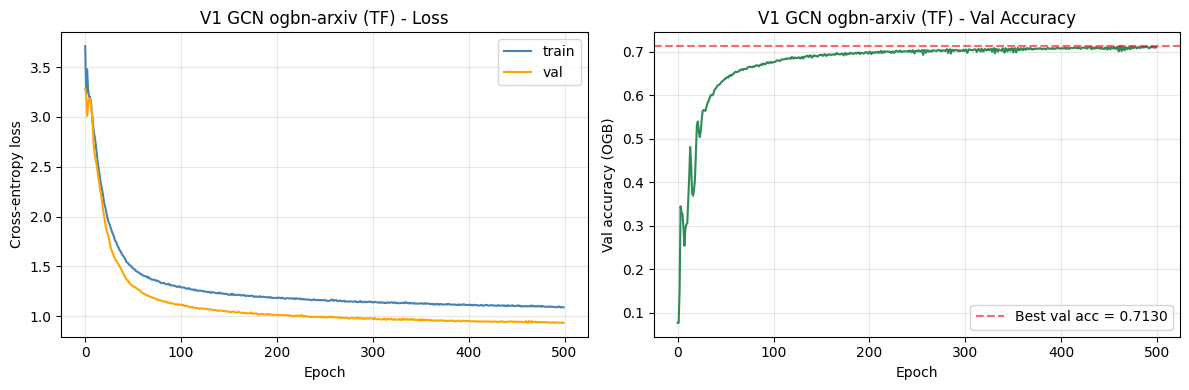

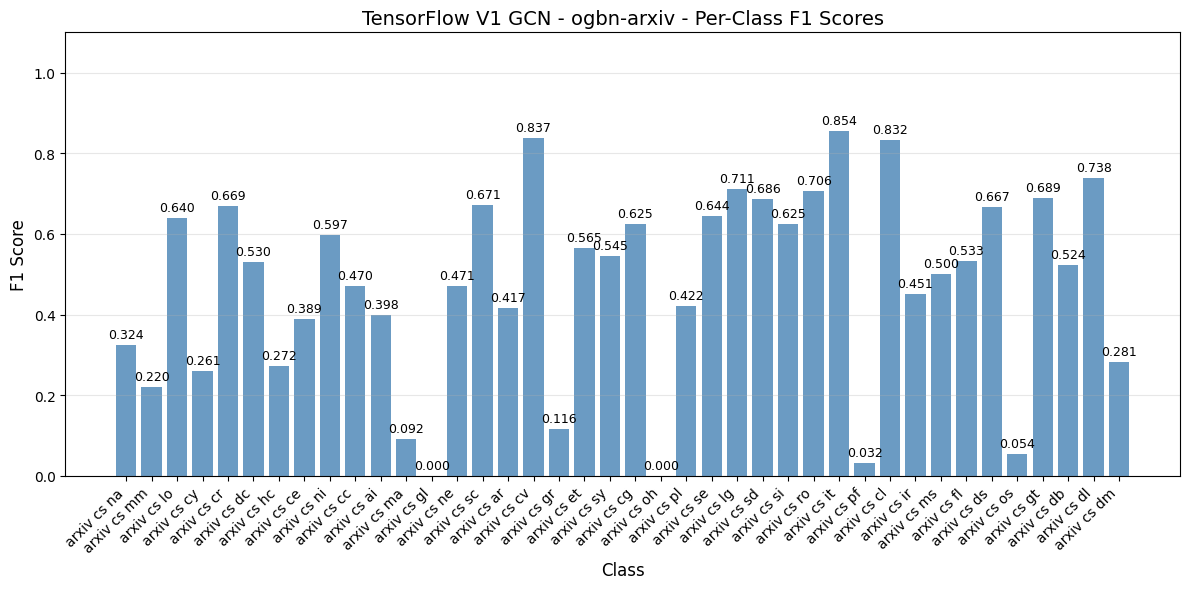


    Checkpoint: /mnt/c/Users/Max/Desktop/Coding/.Projects/2026/ml-framework-comparisons/TensorFlow/18-gnn/results/v1_gcn_arxiv_best.weights.h5
    Model size: 0.42 MB, params: 109,096


In [4]:
# Step 4: V1 GCN on ogbn-arxiv (TF scaled)

"""
Scale-up of V1 GCN matching PT exactly:
  - 3 layers (arxiv needs more hops than Cora's 2)
  - 256 hidden (40 classes need more capacity)
  - 500 epochs, full-batch
  - lr=0.01, wd=0 (OGB baseline convention)
  - No BatchNorm (from-scratch baseline, same as PT V1)

Eager-mode TF on 170K nodes over 500 epochs may take ~2-5 minutes
(vs PT's 26s). If training is too slow, a @tf.function wrapper on
the train step would graph-compile it.
"""


# V1 arxiv hyperparameters (identical to PT V1)
V1_ARXIV_HIDDEN = 256
V1_ARXIV_LAYERS = 3
V1_ARXIV_DROPOUT = 0.5
V1_ARXIV_LR = 0.01
V1_ARXIV_WEIGHT_DECAY = 0.0
V1_ARXIV_EPOCHS = 500
V1_ARXIV_LOG_EVERY = 50

# Load arxiv class names from OGB's shipped mapping
arxiv_mapping_path = os.path.join(
    DATA_ROOT, 'ogbn_arxiv', 'mapping', 'labelidx2arxivcategeory.csv.gz',
)
ARXIV_CLASS_NAMES = pd.read_csv(arxiv_mapping_path)['arxiv category'].tolist()
assert len(ARXIV_CLASS_NAMES) == 40, f"Expected 40, got {len(ARXIV_CLASS_NAMES)}"


def evaluate_ogb_tf(logits, y_true_tensor, evaluator):
    # OGB evaluator wrapper for TF tensors (returns scalar accuracy)
    y_pred = np.argmax(logits.numpy() if hasattr(logits, 'numpy') else np.asarray(logits),
                       axis=-1, keepdims=True)
    y_true_np = y_true_tensor.numpy() if hasattr(y_true_tensor, 'numpy') else np.asarray(y_true_tensor)
    if y_true_np.ndim == 1:
        y_true_np = y_true_np.reshape(-1, 1)
    result = evaluator.eval({'y_true': y_true_np, 'y_pred': y_pred})
    return float(result[evaluator.eval_metric])



# Build sparse A_hat for arxiv once
with tf.device(DEVICE):
    A_hat_arxiv = normalize_adj_symmetric_tf(arxiv['edge_index'], arxiv['num_nodes'])
print(f"A_hat (arxiv): {tuple(A_hat_arxiv.dense_shape.numpy())}, "
      f"nnz={int(A_hat_arxiv.values.shape[0]):,}")


# Model + optimizer
tf.random.set_seed(RANDOM_STATE)
with tf.device(DEVICE):
    model_v1_arxiv = GCN(
        hidden=V1_ARXIV_HIDDEN,
        num_classes=int(tf.reduce_max(arxiv['y'])) + 1,
        num_layers=V1_ARXIV_LAYERS,
        dropout=V1_ARXIV_DROPOUT,
    )
    _ = model_v1_arxiv(arxiv['x'], A_hat_arxiv, training=False)

optimizer = tf.keras.optimizers.Adam(
    learning_rate=V1_ARXIV_LR,
    weight_decay=V1_ARXIV_WEIGHT_DECAY,
)
num_params = int(model_v1_arxiv.count_params())
print(f"Model: {V1_ARXIV_LAYERS}-layer GCN "
      f"({arxiv['num_features']} -> {V1_ARXIV_HIDDEN} -> {V1_ARXIV_HIDDEN} -> "
      f"{int(tf.reduce_max(arxiv['y'])) + 1}), {num_params:,} params")


# Training -- full-batch, indexed via split_idx (not masks)
train_idx = arxiv_split['train']
valid_idx = arxiv_split['valid']
test_idx  = arxiv_split['test']

history = {'train_loss': [], 'val_loss': [], 'val_acc': []}
best_val_acc = 0.0
best_weights = None

if gpus:
    tf.config.experimental.reset_memory_stats('GPU:0')

print(f"\nTraining V1 GCN on ogbn-arxiv ({V1_ARXIV_EPOCHS} epochs)...")
with track_performance() as perf:
    for epoch in range(V1_ARXIV_EPOCHS):
        # Train step
        with tf.GradientTape() as tape:
            logits = model_v1_arxiv(arxiv['x'], A_hat_arxiv, training=True)
            train_logits = tf.gather(logits, train_idx)
            train_labels = tf.gather(arxiv['y'], train_idx)
            train_loss = tf.reduce_mean(
                tf.nn.sparse_softmax_cross_entropy_with_logits(
                    labels=train_labels, logits=train_logits,
                )
            )
        grads = tape.gradient(train_loss, model_v1_arxiv.trainable_variables)
        optimizer.apply_gradients(zip(grads, model_v1_arxiv.trainable_variables))

        # Eval
        val_logits_full = model_v1_arxiv(arxiv['x'], A_hat_arxiv, training=False)
        val_logits = tf.gather(val_logits_full, valid_idx)
        val_labels = tf.gather(arxiv['y'], valid_idx)
        val_loss = tf.reduce_mean(
            tf.nn.sparse_softmax_cross_entropy_with_logits(
                labels=val_labels, logits=val_logits,
            )
        )
        val_acc = evaluate_ogb_tf(val_logits, val_labels, arxiv_evaluator)

        history['train_loss'].append(float(train_loss))
        history['val_loss'].append(float(val_loss))
        history['val_acc'].append(val_acc)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_weights = [w.numpy() for w in model_v1_arxiv.weights]

        if (epoch + 1) % V1_ARXIV_LOG_EVERY == 0 or epoch == 0:
            print(f"    ep {epoch + 1:3d}: train_loss={float(train_loss):.4f}, "
                  f"val_loss={float(val_loss):.4f}, val_acc={val_acc:.4f}")

peak_gpu_mb = (
    tf.config.experimental.get_memory_info('GPU:0')['peak'] / 1024 / 1024
    if gpus else 0.0
)
print(f"\n    Train time: {perf['time']:.2f}s, peak GPU memory: {peak_gpu_mb:.1f} MB")
print(f"    Best val acc: {best_val_acc:.4f}")


# Test eval with best weights
for w, best in zip(model_v1_arxiv.weights, best_weights):
    w.assign(best)

test_logits_full = model_v1_arxiv(arxiv['x'], A_hat_arxiv, training=False).numpy()
test_idx_np = test_idx.numpy()
train_idx_np = train_idx.numpy()
test_true = arxiv['y'].numpy()[test_idx_np]
train_true = arxiv['y'].numpy()[train_idx_np]
test_probs = tf.nn.softmax(test_logits_full[test_idx_np], axis=-1).numpy()
test_pred = test_logits_full[test_idx_np].argmax(axis=-1)
train_pred = test_logits_full[train_idx_np].argmax(axis=-1)

ogb_acc = evaluate_ogb_tf(test_logits_full[test_idx_np], arxiv['y'].numpy()[test_idx_np], arxiv_evaluator)
print(f"\n    OGB official test accuracy: {ogb_acc:.4f}")

test_metrics = evaluate_classifier(test_true, test_pred, test_probs)
train_metrics = evaluate_classifier(train_true, train_pred)
print_metrics(train_metrics, test_metrics, title="V1 GCN - ogbn-arxiv (TF)")


# Inference + viz + log
def _predict_arxiv(_):
    return model_v1_arxiv(arxiv['x'], A_hat_arxiv, training=False).numpy().argmax(axis=-1)
inference_stats = track_inference(_predict_arxiv, arxiv['x'], n_runs=20)
print(f"    Inference (full-graph): "
      f"total {inference_stats['total_time'] * 1000:.1f} ms, "
      f"{inference_stats['samples_per_sec']:,.0f} samples/sec")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history['train_loss'], label='train', color='steelblue')
axes[0].plot(history['val_loss'], label='val', color='orange')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Cross-entropy loss')
axes[0].set_title('V1 GCN ogbn-arxiv (TF) - Loss'); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].plot(history['val_acc'], color='seagreen')
axes[1].axhline(best_val_acc, color='red', ls='--', alpha=0.6,
                label=f'Best val acc = {best_val_acc:.4f}')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Val accuracy (OGB)')
axes[1].set_title('V1 GCN ogbn-arxiv (TF) - Val Accuracy'); axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'v1_gcn_arxiv_training_curves.png'),
            dpi=150, bbox_inches='tight')
plt.show()

plot_per_class_f1(
    test_true, test_pred, ARXIV_CLASS_NAMES,
    framework='TensorFlow V1 GCN - ogbn-arxiv',
    save_path=os.path.join(RESULTS_DIR, 'v1_gcn_arxiv_per_class_f1.png'),
)

model_size_bytes = int(sum(w.numpy().nbytes for w in model_v1_arxiv.weights))
arxiv_variants.append({
    'variant': 'V1 GCN',
    'test_metrics': test_metrics,
    'ogb_acc': ogb_acc,
    'perf': {**perf, 'gpu_memory': peak_gpu_mb},
    'inference_stats': inference_stats,
    'model_size_bytes': model_size_bytes,
    'num_params': num_params,
    'history': history,
    'best_val_acc': best_val_acc,
})

ckpt_path = os.path.join(RESULTS_DIR, 'v1_gcn_arxiv_best.weights.h5')
model_v1_arxiv.save_weights(ckpt_path)
print(f"\n    Checkpoint: {ckpt_path}")
print(f"    Model size: {model_size_bytes / 1024 / 1024:.2f} MB, params: {num_params:,}")

In [5]:
# Step 5: GAT Layer + Model

"""
TF-native GAT matching our PyTorch GATLayer exactly:

Per-edge attention (split form, saves memory vs full concat):
    e_ij = LeakyReLU( a_src^T (W h_i) + a_dst^T (W h_j) )
    alpha_ij = softmax over j in N(i) of e_ij

Multi-head concat for intermediate layers; average for output.
Primitives: Dense + tf.math.unsorted_segment_max/sum + tf.gather.
"""


def segment_softmax_tf(scores, target_idx, num_nodes):
    """
    Softmax over edges grouped by target node.
    Numerically stable via per-segment max subtraction.

    Args:
        scores: (E,) or (E, H) attention logits per edge.
        target_idx: (E,) int64 edge target (edge_index[1]).
        num_nodes: int N.

    Returns:
        Same shape as scores, normalized so per-target incoming edges sum to 1.
    """
    seg_max = tf.math.unsorted_segment_max(scores, target_idx, num_segments=num_nodes)
    shifted = scores - tf.gather(seg_max, target_idx)
    exp_scores = tf.exp(shifted)
    seg_sum = tf.math.unsorted_segment_sum(exp_scores, target_idx, num_segments=num_nodes)
    return exp_scores / tf.gather(seg_sum, target_idx)


def add_self_loops_tf(edge_index, num_nodes):
    # Append self-loop (i, i) edges to edge_index. Returns (2, E + N) int64
    self_loops = tf.stack([tf.range(num_nodes, dtype=tf.int64)] * 2)
    return tf.concat([edge_index, self_loops], axis=1)


class GATLayer(tf.keras.layers.Layer):
    """
    Multi-head GAT layer from primitives.

    call(x, edge_index_sl):
        x: (N, in_features)
        edge_index_sl: (2, E + N) -- MUST include self-loops
    Returns:
        (N, num_heads * out_features) if concat else (N, out_features)
    """

    def __init__(self, out_features, num_heads,
                 concat=True, dropout=0.6, leaky_slope=0.2, **kwargs):
        super().__init__(**kwargs)
        self.out_features = out_features
        self.num_heads = num_heads
        self.concat = concat
        self.dropout_rate = dropout
        self.leaky_slope = leaky_slope

        # Per-head linear projection (output dim = num_heads * out_features)
        self.lin = tf.keras.layers.Dense(num_heads * out_features, use_bias=False)

        # Attention parameters (split form: a = [a_src, a_dst])
        self.att_src = self.add_weight(
            name='att_src', shape=(1, num_heads, out_features),
            initializer='glorot_uniform', trainable=True,
        )
        self.att_dst = self.add_weight(
            name='att_dst', shape=(1, num_heads, out_features),
            initializer='glorot_uniform', trainable=True,
        )

        # Bias
        bias_dim = num_heads * out_features if concat else out_features
        self.bias = self.add_weight(
            name='bias', shape=(bias_dim,),
            initializer='zeros', trainable=True,
        )

    def call(self, x, edge_index_sl, training=False):
        N = tf.shape(x)[0]

        # Linear projection, reshape to (N, H, D)
        h = self.lin(x)
        h = tf.reshape(h, (-1, self.num_heads, self.out_features))

        # Per-node, per-head scalar contributions (split attention)
        alpha_src_per_node = tf.reduce_sum(h * self.att_src, axis=-1)  # (N, H)
        alpha_dst_per_node = tf.reduce_sum(h * self.att_dst, axis=-1)  # (N, H)

        src = edge_index_sl[0]
        dst = edge_index_sl[1]
        e = tf.gather(alpha_src_per_node, src) + tf.gather(alpha_dst_per_node, dst)  # (E_sl, H)
        e = tf.nn.leaky_relu(e, alpha=self.leaky_slope)

        # Softmax over incoming edges per destination node
        alpha = segment_softmax_tf(e, dst, num_nodes=N)  # (E_sl, H)
        if training and self.dropout_rate > 0:
            alpha = tf.nn.dropout(alpha, rate=self.dropout_rate)

        # Aggregate: for each edge (s, d), message = alpha[s, d, head] * h[s, head, :]
        msg = tf.gather(h, src) * tf.expand_dims(alpha, -1)   # (E_sl, H, D)
        out = tf.math.unsorted_segment_sum(msg, dst, num_segments=N)  # (N, H, D)

        if self.concat:
            out = tf.reshape(out, (-1, self.num_heads * self.out_features))
        else:
            out = tf.reduce_mean(out, axis=1)   # average heads -> (N, D)

        return out + self.bias


class GAT(tf.keras.Model):
    """
    2-layer GAT (Velickovic recipe for Cora):
        Layer 1: 8 heads of 8 features, concat -> 64 hidden
        Layer 2: 1 head of num_classes features, averaged -> logits
    """

    def __init__(self, hidden_per_head, num_classes,
                 num_heads=8, dropout=0.6, **kwargs):
        super().__init__(**kwargs)
        self.dropout_rate = dropout
        self.gat1 = GATLayer(
            hidden_per_head, num_heads, concat=True, dropout=dropout,
        )
        self.gat2 = GATLayer(
            num_classes, num_heads=1, concat=False, dropout=dropout,
        )

    def call(self, x, edge_index_sl, training=False):
        if training and self.dropout_rate > 0:
            x = tf.nn.dropout(x, rate=self.dropout_rate)
        x = tf.nn.elu(self.gat1(x, edge_index_sl, training=training))
        if training and self.dropout_rate > 0:
            x = tf.nn.dropout(x, rate=self.dropout_rate)
        return self.gat2(x, edge_index_sl, training=training)



# Sanity test on Cora (shape + param parity check vs PT)
with tf.device(DEVICE):
    _cora_ei_sl = add_self_loops_tf(cora['edge_index'], cora['num_nodes'])
    _test_gat = GAT(
        hidden_per_head=8,
        num_classes=int(tf.reduce_max(cora['y'])) + 1,
        num_heads=8,
        dropout=0.6,
    )
    _test_logits = _test_gat(cora['x'], _cora_ei_sl, training=False)

print(f"GAT sanity test on Cora:")
print(f"    Input x:             {tuple(cora['x'].shape)}  {cora['x'].dtype.name}")
print(f"    edge_index w/ loops: {tuple(_cora_ei_sl.shape)}  ({_cora_ei_sl.shape[1]:,} edges)")
print(f"    Output logits:       {tuple(_test_logits.shape)}  {_test_logits.dtype.name}")
print(f"    Total params:        {_test_gat.count_params():,}  (PT parity: 92,373)")

del _cora_ei_sl, _test_gat, _test_logits

GAT sanity test on Cora:
    Input x:             (2708, 1433)  float32
    edge_index w/ loops: (2, 13264)  (13,264 edges)
    Output logits:       (2708, 7)  float32
    Total params:        92,373  (PT parity: 92,373)


Cora edge_index with self-loops: 10,556 -> 13,264 edges
Model: 2-layer GAT (1433 -> [8x8=64 concat] -> [1x7 avg]), 92,373 params

Training V3 GAT on Cora (200 epochs)...
    ep   1: train_loss=1.9456, val_loss=1.9465, val_acc=0.1760
    ep  20: train_loss=1.7714, val_loss=1.8305, val_acc=0.7720
    ep  40: train_loss=1.4680, val_loss=1.6157, val_acc=0.8040
    ep  60: train_loss=1.0689, val_loss=1.3397, val_acc=0.7960
    ep  80: train_loss=1.0067, val_loss=1.0898, val_acc=0.7940
    ep 100: train_loss=0.7399, val_loss=0.9430, val_acc=0.7880
    ep 120: train_loss=0.6866, val_loss=0.8371, val_acc=0.7920
    ep 140: train_loss=0.6188, val_loss=0.7857, val_acc=0.7880
    ep 160: train_loss=0.6114, val_loss=0.7242, val_acc=0.7900
    ep 180: train_loss=0.5173, val_loss=0.7056, val_acc=0.7880
    ep 200: train_loss=0.4820, val_loss=0.6813, val_acc=0.7920

    Train time: 21.97s, peak GPU memory: 369.8 MB
    Best val acc: 0.8040

METRICS — V3 GAT - Cora (TF)
Metric                         

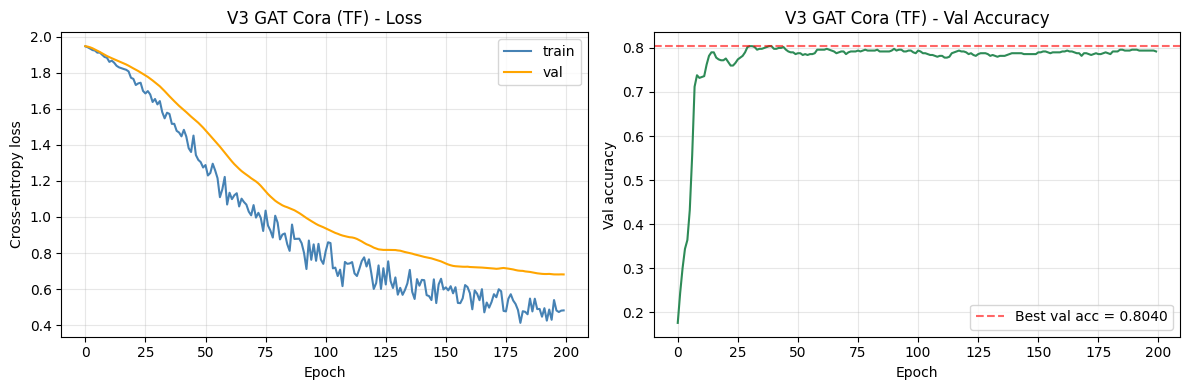

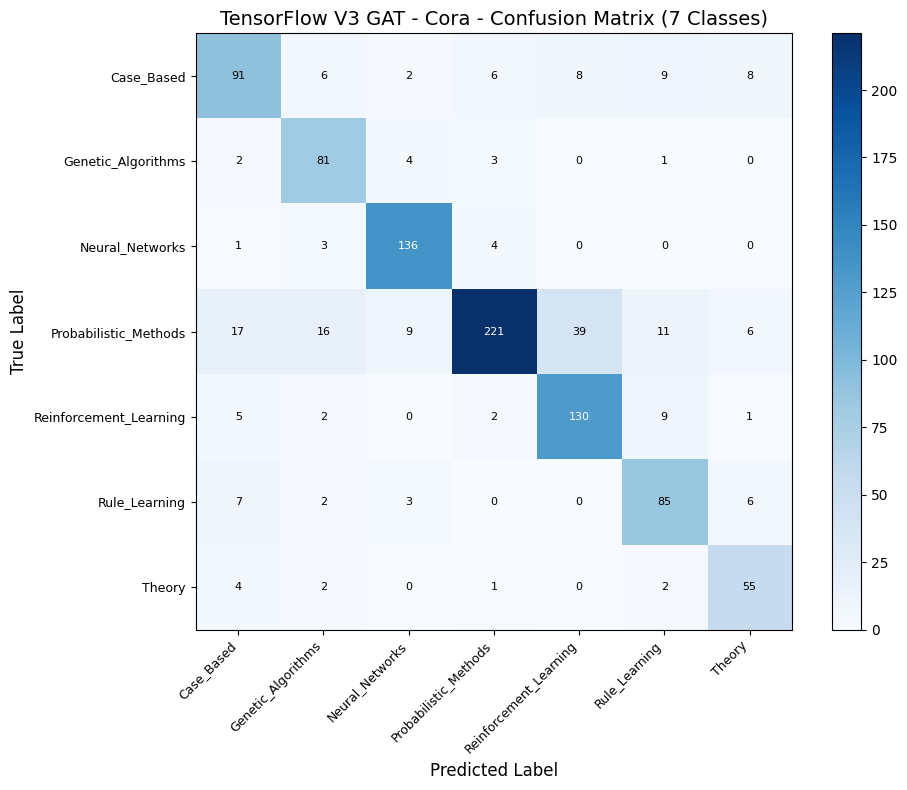

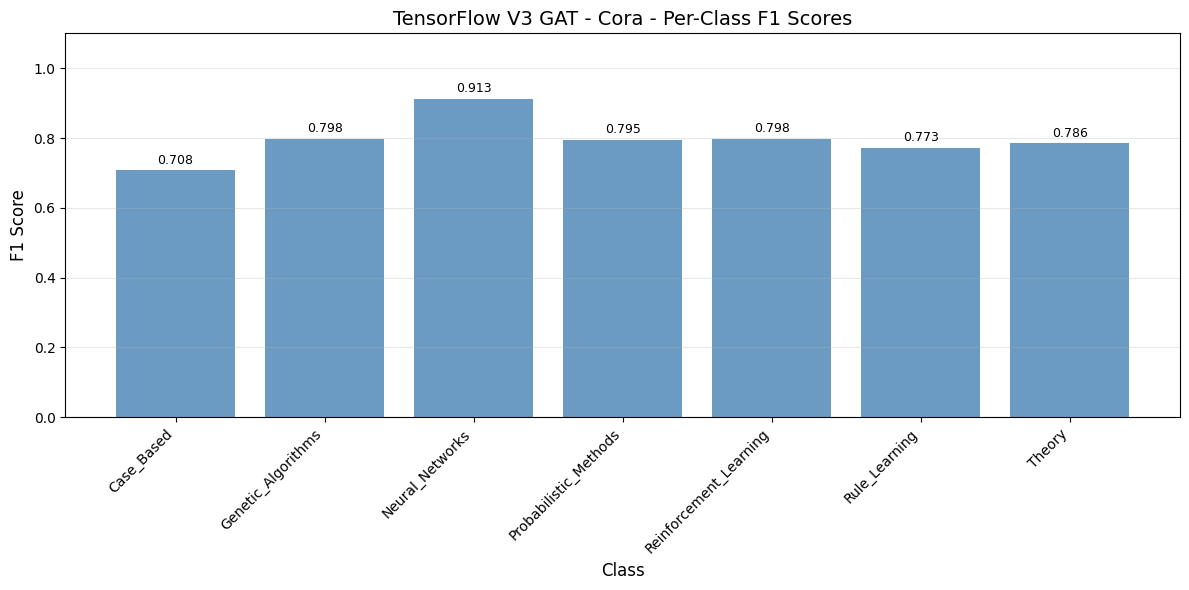


    Checkpoint: /mnt/c/Users/Max/Desktop/Coding/.Projects/2026/ml-framework-comparisons/TensorFlow/18-gnn/results/v3_gat_cora_best.weights.h5
    Model size: 360.83 KB, params: 92,373


In [6]:
# Step 6: V3 GAT on Cora (TF training + test + viz)

"""
Velickovic 2018 recipe on Cora in TF -- matches PT V3 hyperparameters
exactly (8 heads x 8 features, dropout 0.6, lr 0.005, wd 5e-4, grad clip 1.0).
"""

# V3 Cora hyperparameters (Velickovic 2018 recipe, identical to PT)
V3_CORA_HIDDEN_PER_HEAD = 8
V3_CORA_NUM_HEADS = 8
V3_CORA_DROPOUT = 0.6
V3_CORA_LR = 0.005
V3_CORA_WEIGHT_DECAY = 5e-4
V3_CORA_EPOCHS = 200
V3_CORA_LOG_EVERY = 20


# Precompute self-loop-augmented edge_index once (graph constant)
with tf.device(DEVICE):
    cora_edge_index_sl = add_self_loops_tf(cora['edge_index'], cora['num_nodes'])
print(f"Cora edge_index with self-loops: "
      f"{cora['edge_index'].shape[1]:,} -> {cora_edge_index_sl.shape[1]:,} edges")


# Model + optimizer
tf.random.set_seed(RANDOM_STATE)
with tf.device(DEVICE):
    model_v3_cora = GAT(
        hidden_per_head=V3_CORA_HIDDEN_PER_HEAD,
        num_classes=int(tf.reduce_max(cora['y'])) + 1,
        num_heads=V3_CORA_NUM_HEADS,
        dropout=V3_CORA_DROPOUT,
    )
    _ = model_v3_cora(cora['x'], cora_edge_index_sl, training=False)

optimizer = tf.keras.optimizers.Adam(
    learning_rate=V3_CORA_LR, weight_decay=V3_CORA_WEIGHT_DECAY,
)
num_params = int(model_v3_cora.count_params())
print(f"Model: 2-layer GAT "
      f"({cora['num_features']} -> [{V3_CORA_NUM_HEADS}x{V3_CORA_HIDDEN_PER_HEAD}=64 concat] "
      f"-> [1x7 avg]), {num_params:,} params")


# Training -- full-batch, transductive, gradient clipping for attention stability
history = {'train_loss': [], 'val_loss': [], 'val_acc': []}
best_val_acc = 0.0
best_weights = None

if gpus:
    tf.config.experimental.reset_memory_stats('GPU:0')

print(f"\nTraining V3 GAT on Cora ({V3_CORA_EPOCHS} epochs)...")
with track_performance() as perf:
    for epoch in range(V3_CORA_EPOCHS):
        # Train step with grad clipping (attention can be unstable early)
        with tf.GradientTape() as tape:
            logits = model_v3_cora(cora['x'], cora_edge_index_sl, training=True)
            train_logits = tf.boolean_mask(logits, cora['train_mask'])
            train_labels = tf.boolean_mask(cora['y'], cora['train_mask'])
            train_loss = tf.reduce_mean(
                tf.nn.sparse_softmax_cross_entropy_with_logits(
                    labels=train_labels, logits=train_logits,
                )
            )
        grads = tape.gradient(train_loss, model_v3_cora.trainable_variables)
        # Clip global norm at 1.0 (matches PT grad_clip_norm)
        grads, _ = tf.clip_by_global_norm(grads, clip_norm=1.0)
        optimizer.apply_gradients(zip(grads, model_v3_cora.trainable_variables))

        # Eval
        val_logits_full = model_v3_cora(cora['x'], cora_edge_index_sl, training=False)
        val_logits = tf.boolean_mask(val_logits_full, cora['val_mask'])
        val_labels = tf.boolean_mask(cora['y'], cora['val_mask'])
        val_loss = tf.reduce_mean(
            tf.nn.sparse_softmax_cross_entropy_with_logits(
                labels=val_labels, logits=val_logits,
            )
        )
        val_pred = tf.argmax(val_logits, axis=-1, output_type=tf.int64)
        val_acc = float(tf.reduce_mean(tf.cast(val_pred == val_labels, tf.float32)))

        history['train_loss'].append(float(train_loss))
        history['val_loss'].append(float(val_loss))
        history['val_acc'].append(val_acc)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_weights = [w.numpy() for w in model_v3_cora.weights]

        if (epoch + 1) % V3_CORA_LOG_EVERY == 0 or epoch == 0:
            print(f"    ep {epoch + 1:3d}: train_loss={float(train_loss):.4f}, "
                  f"val_loss={float(val_loss):.4f}, val_acc={val_acc:.4f}")

peak_gpu_mb = (
    tf.config.experimental.get_memory_info('GPU:0')['peak'] / 1024 / 1024
    if gpus else 0.0
)
print(f"\n    Train time: {perf['time']:.2f}s, peak GPU memory: {peak_gpu_mb:.1f} MB")
print(f"    Best val acc: {best_val_acc:.4f}")


# Restore best weights, test eval
for w, best in zip(model_v3_cora.weights, best_weights):
    w.assign(best)

test_logits_full = model_v3_cora(cora['x'], cora_edge_index_sl, training=False).numpy()
test_mask_np = cora['test_mask'].numpy()
train_mask_np = cora['train_mask'].numpy()
test_true = cora['y'].numpy()[test_mask_np]
train_true = cora['y'].numpy()[train_mask_np]
test_probs = tf.nn.softmax(test_logits_full[test_mask_np], axis=-1).numpy()
test_pred = test_logits_full[test_mask_np].argmax(axis=-1)
train_pred = test_logits_full[train_mask_np].argmax(axis=-1)

test_metrics = evaluate_classifier(test_true, test_pred, test_probs)
train_metrics = evaluate_classifier(train_true, train_pred)
print_metrics(train_metrics, test_metrics, title="V3 GAT - Cora (TF)")


# Inference + viz + log
def _predict_v3_cora(_):
    return model_v3_cora(cora['x'], cora_edge_index_sl, training=False).numpy().argmax(axis=-1)
inference_stats = track_inference(_predict_v3_cora, cora['x'], n_runs=50)
print(f"    Inference: {inference_stats['per_sample_us']:.2f} us/sample, "
      f"{inference_stats['samples_per_sec']:,.0f} samples/sec")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history['train_loss'], label='train', color='steelblue')
axes[0].plot(history['val_loss'], label='val', color='orange')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Cross-entropy loss')
axes[0].set_title('V3 GAT Cora (TF) - Loss'); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].plot(history['val_acc'], color='seagreen')
axes[1].axhline(best_val_acc, color='red', ls='--', alpha=0.6,
                label=f'Best val acc = {best_val_acc:.4f}')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Val accuracy')
axes[1].set_title('V3 GAT Cora (TF) - Val Accuracy'); axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'v3_gat_cora_training_curves.png'),
            dpi=150, bbox_inches='tight')
plt.show()

plot_confusion_matrix_multiclass(
    test_true, test_pred, CORA_CLASS_NAMES,
    framework='TensorFlow V3 GAT - Cora',
    save_path=os.path.join(RESULTS_DIR, 'v3_gat_cora_confusion.png'),
)
plot_per_class_f1(
    test_true, test_pred, CORA_CLASS_NAMES,
    framework='TensorFlow V3 GAT - Cora',
    save_path=os.path.join(RESULTS_DIR, 'v3_gat_cora_per_class_f1.png'),
)

model_size_bytes = int(sum(w.numpy().nbytes for w in model_v3_cora.weights))
cora_variants.append({
    'variant': 'V3 GAT',
    'test_metrics': test_metrics,
    'perf': {**perf, 'gpu_memory': peak_gpu_mb},
    'inference_stats': inference_stats,
    'model_size_bytes': model_size_bytes,
    'num_params': num_params,
    'history': history,
    'best_val_acc': best_val_acc,
})

ckpt_path = os.path.join(RESULTS_DIR, 'v3_gat_cora_best.weights.h5')
model_v3_cora.save_weights(ckpt_path)
print(f"\n    Checkpoint: {ckpt_path}")
print(f"    Model size: {model_size_bytes / 1024:.2f} KB, params: {num_params:,}")

arxiv edge_index with self-loops: 2,315,598 -> 2,484,941 edges
Model: 3-layer GAT (128 -> [2x128=256 concat] -> [2x128=256 concat] -> [1x40 avg]), 110,200 params  (PT parity: 110,200)

Training V3 GAT on ogbn-arxiv (500 epochs)...
    ep   1: train_loss=3.7522, val_loss=3.3486, val_acc=0.0763
    ep  50: train_loss=1.3559, val_loss=1.1249, val_acc=0.6627
    ep 100: train_loss=1.2548, val_loss=1.0297, val_acc=0.6861
    ep 150: train_loss=1.2296, val_loss=0.9994, val_acc=0.6953
    ep 200: train_loss=1.2010, val_loss=0.9844, val_acc=0.6997
    ep 250: train_loss=1.1874, val_loss=0.9717, val_acc=0.7012
    ep 300: train_loss=1.1754, val_loss=0.9681, val_acc=0.7029
    ep 350: train_loss=1.1673, val_loss=0.9560, val_acc=0.7053
    ep 400: train_loss=1.1614, val_loss=0.9572, val_acc=0.7033
    ep 450: train_loss=1.1483, val_loss=0.9445, val_acc=0.7084
    ep 500: train_loss=1.1429, val_loss=0.9439, val_acc=0.7080

    Train time: 123.32s, peak GPU memory: 15967.7 MB
    Best val acc: 0.70

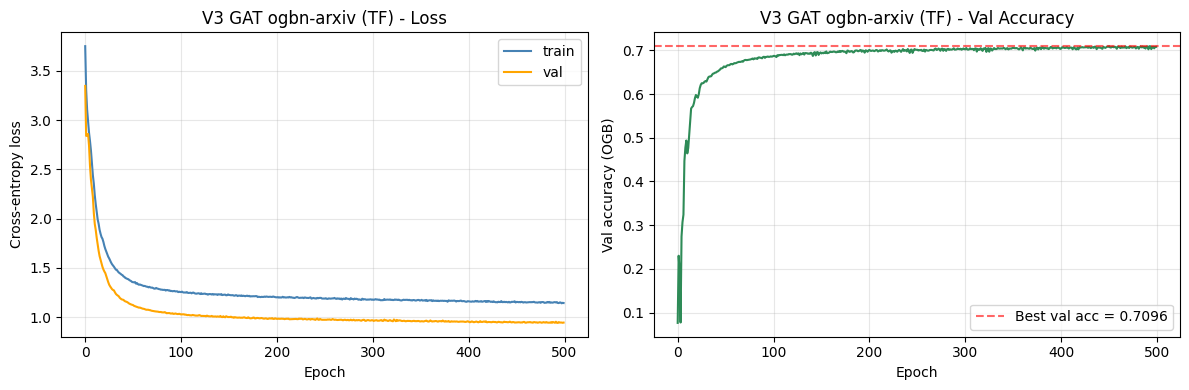

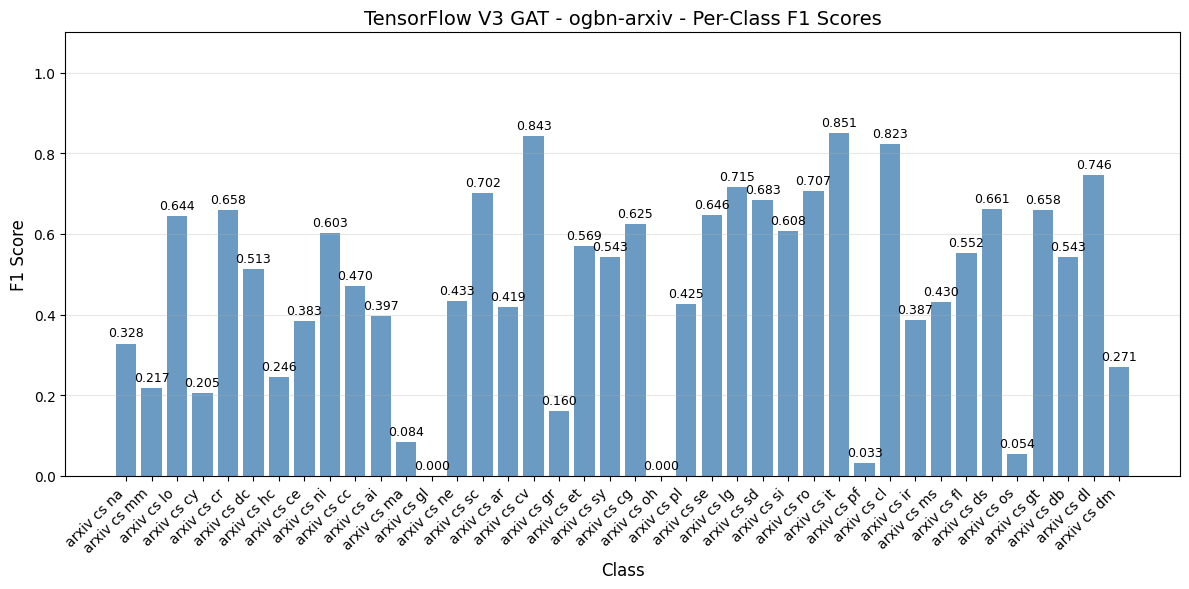


    Checkpoint: /mnt/c/Users/Max/Desktop/Coding/.Projects/2026/ml-framework-comparisons/TensorFlow/18-gnn/results/v3_gat_arxiv_best.weights.h5
    Model size: 0.42 MB, params: 110,200


In [7]:
# Step 7: V3 GAT on ogbn-arxiv

"""
3-layer GAT on arxiv in TF -- matches PT V3 arxiv config:
  2 heads x 128 features (keeps peak attention memory manageable)
  Concat-concat-average pattern
  lr 0.005, wd 0, dropout 0.3, 500 epochs, grad clip 1.0

Memory estimate per layer forward:
    h[src] shape: (2.48M edges, 2 heads, 128 dim) ~ 2.5 GB
    msg:          same shape                       ~ 2.5 GB
    Active across 3 layers + backward: 10-15 GB (fits on 24 GB)

TF eager-mode overhead may push peak GPU above PT's 13.4 GB observed.
"""


class GAT3Layer(tf.keras.Model):
    """
    3-layer GAT for arxiv: concat -> concat -> average.
    Layer 1: in -> H*D (concat)
    Layer 2: H*D -> H*D (concat)
    Layer 3: H*D -> num_classes (1 head, average)
    """

    def __init__(self, hidden_per_head, num_classes,
                 num_heads=2, dropout=0.3, **kwargs):
        super().__init__(**kwargs)
        self.dropout_rate = dropout
        self.gat1 = GATLayer(
            hidden_per_head, num_heads, concat=True, dropout=dropout,
        )
        self.gat2 = GATLayer(
            hidden_per_head, num_heads, concat=True, dropout=dropout,
        )
        self.gat3 = GATLayer(
            num_classes, num_heads=1, concat=False, dropout=dropout,
        )

    def call(self, x, edge_index_sl, training=False):
        if training and self.dropout_rate > 0:
            x = tf.nn.dropout(x, rate=self.dropout_rate)
        x = tf.nn.elu(self.gat1(x, edge_index_sl, training=training))
        if training and self.dropout_rate > 0:
            x = tf.nn.dropout(x, rate=self.dropout_rate)
        x = tf.nn.elu(self.gat2(x, edge_index_sl, training=training))
        if training and self.dropout_rate > 0:
            x = tf.nn.dropout(x, rate=self.dropout_rate)
        return self.gat3(x, edge_index_sl, training=training)


# V3 arxiv hyperparameters (identical to PT V3 arxiv)
V3_ARXIV_HIDDEN_PER_HEAD = 128
V3_ARXIV_NUM_HEADS = 2
V3_ARXIV_LAYERS = 3
V3_ARXIV_DROPOUT = 0.3
V3_ARXIV_LR = 0.005
V3_ARXIV_WEIGHT_DECAY = 0.0
V3_ARXIV_EPOCHS = 500
V3_ARXIV_LOG_EVERY = 50


# Precompute self-loop-augmented edge_index once
with tf.device(DEVICE):
    arxiv_edge_index_sl = add_self_loops_tf(arxiv['edge_index'], arxiv['num_nodes'])
print(f"arxiv edge_index with self-loops: "
      f"{arxiv['edge_index'].shape[1]:,} -> {arxiv_edge_index_sl.shape[1]:,} edges")

"""
Free V1's sparse A_hat if it still references GPU memory (not strictly needed
but defensive before V3's attention intermediates claim their share)
"""
try:
    del A_hat_arxiv
except NameError:
    pass


# Model + optimizer
tf.random.set_seed(RANDOM_STATE)
with tf.device(DEVICE):
    model_v3_arxiv = GAT3Layer(
        hidden_per_head=V3_ARXIV_HIDDEN_PER_HEAD,
        num_classes=int(tf.reduce_max(arxiv['y'])) + 1,
        num_heads=V3_ARXIV_NUM_HEADS,
        dropout=V3_ARXIV_DROPOUT,
    )
    _ = model_v3_arxiv(arxiv['x'], arxiv_edge_index_sl, training=False)

optimizer = tf.keras.optimizers.Adam(
    learning_rate=V3_ARXIV_LR, weight_decay=V3_ARXIV_WEIGHT_DECAY,
)
num_params = int(model_v3_arxiv.count_params())
print(f"Model: 3-layer GAT "
      f"({arxiv['num_features']} -> "
      f"[{V3_ARXIV_NUM_HEADS}x{V3_ARXIV_HIDDEN_PER_HEAD}=256 concat] -> "
      f"[{V3_ARXIV_NUM_HEADS}x{V3_ARXIV_HIDDEN_PER_HEAD}=256 concat] -> "
      f"[1x40 avg]), "
      f"{num_params:,} params  (PT parity: 110,200)")


# Training
train_idx = arxiv_split['train']
valid_idx = arxiv_split['valid']
test_idx  = arxiv_split['test']

history = {'train_loss': [], 'val_loss': [], 'val_acc': []}
best_val_acc = 0.0
best_weights = None

if gpus:
    tf.config.experimental.reset_memory_stats('GPU:0')

print(f"\nTraining V3 GAT on ogbn-arxiv ({V3_ARXIV_EPOCHS} epochs)...")
with track_performance() as perf:
    for epoch in range(V3_ARXIV_EPOCHS):
        with tf.GradientTape() as tape:
            logits = model_v3_arxiv(arxiv['x'], arxiv_edge_index_sl, training=True)
            train_logits = tf.gather(logits, train_idx)
            train_labels = tf.gather(arxiv['y'], train_idx)
            train_loss = tf.reduce_mean(
                tf.nn.sparse_softmax_cross_entropy_with_logits(
                    labels=train_labels, logits=train_logits,
                )
            )
        grads = tape.gradient(train_loss, model_v3_arxiv.trainable_variables)
        grads, _ = tf.clip_by_global_norm(grads, clip_norm=1.0)
        optimizer.apply_gradients(zip(grads, model_v3_arxiv.trainable_variables))

        val_logits_full = model_v3_arxiv(arxiv['x'], arxiv_edge_index_sl, training=False)
        val_logits = tf.gather(val_logits_full, valid_idx)
        val_labels = tf.gather(arxiv['y'], valid_idx)
        val_loss = tf.reduce_mean(
            tf.nn.sparse_softmax_cross_entropy_with_logits(
                labels=val_labels, logits=val_logits,
            )
        )
        val_acc = evaluate_ogb_tf(val_logits, val_labels, arxiv_evaluator)

        history['train_loss'].append(float(train_loss))
        history['val_loss'].append(float(val_loss))
        history['val_acc'].append(val_acc)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_weights = [w.numpy() for w in model_v3_arxiv.weights]

        if (epoch + 1) % V3_ARXIV_LOG_EVERY == 0 or epoch == 0:
            print(f"    ep {epoch + 1:3d}: train_loss={float(train_loss):.4f}, "
                  f"val_loss={float(val_loss):.4f}, val_acc={val_acc:.4f}")

peak_gpu_mb = (
    tf.config.experimental.get_memory_info('GPU:0')['peak'] / 1024 / 1024
    if gpus else 0.0
)
print(f"\n    Train time: {perf['time']:.2f}s, peak GPU memory: {peak_gpu_mb:.1f} MB")
print(f"    Best val acc: {best_val_acc:.4f}")


# Test eval
for w, best in zip(model_v3_arxiv.weights, best_weights):
    w.assign(best)

test_logits_full = model_v3_arxiv(arxiv['x'], arxiv_edge_index_sl, training=False).numpy()
test_idx_np = test_idx.numpy()
train_idx_np = train_idx.numpy()
test_true = arxiv['y'].numpy()[test_idx_np]
train_true = arxiv['y'].numpy()[train_idx_np]
test_probs = tf.nn.softmax(test_logits_full[test_idx_np], axis=-1).numpy()
test_pred = test_logits_full[test_idx_np].argmax(axis=-1)
train_pred = test_logits_full[train_idx_np].argmax(axis=-1)

ogb_acc = evaluate_ogb_tf(test_logits_full[test_idx_np], arxiv['y'].numpy()[test_idx_np], arxiv_evaluator)
print(f"\n    OGB official test accuracy: {ogb_acc:.4f}")

test_metrics = evaluate_classifier(test_true, test_pred, test_probs)
train_metrics = evaluate_classifier(train_true, train_pred)
print_metrics(train_metrics, test_metrics, title="V3 GAT - ogbn-arxiv (TF)")


# Inference + viz + log
def _predict_v3_arxiv(_):
    return model_v3_arxiv(arxiv['x'], arxiv_edge_index_sl, training=False).numpy().argmax(axis=-1)
inference_stats = track_inference(_predict_v3_arxiv, arxiv['x'], n_runs=10)
print(f"    Inference (full-graph): "
      f"total {inference_stats['total_time'] * 1000:.1f} ms, "
      f"{inference_stats['samples_per_sec']:,.0f} samples/sec")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history['train_loss'], label='train', color='steelblue')
axes[0].plot(history['val_loss'], label='val', color='orange')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Cross-entropy loss')
axes[0].set_title('V3 GAT ogbn-arxiv (TF) - Loss'); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].plot(history['val_acc'], color='seagreen')
axes[1].axhline(best_val_acc, color='red', ls='--', alpha=0.6,
                label=f'Best val acc = {best_val_acc:.4f}')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Val accuracy (OGB)')
axes[1].set_title('V3 GAT ogbn-arxiv (TF) - Val Accuracy'); axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'v3_gat_arxiv_training_curves.png'),
            dpi=150, bbox_inches='tight')
plt.show()

plot_per_class_f1(
    test_true, test_pred, ARXIV_CLASS_NAMES,
    framework='TensorFlow V3 GAT - ogbn-arxiv',
    save_path=os.path.join(RESULTS_DIR, 'v3_gat_arxiv_per_class_f1.png'),
)

model_size_bytes = int(sum(w.numpy().nbytes for w in model_v3_arxiv.weights))
arxiv_variants.append({
    'variant': 'V3 GAT',
    'test_metrics': test_metrics,
    'ogb_acc': ogb_acc,
    'perf': {**perf, 'gpu_memory': peak_gpu_mb},
    'inference_stats': inference_stats,
    'model_size_bytes': model_size_bytes,
    'num_params': num_params,
    'history': history,
    'best_val_acc': best_val_acc,
})

ckpt_path = os.path.join(RESULTS_DIR, 'v3_gat_arxiv_best.weights.h5')
model_v3_arxiv.save_weights(ckpt_path)
print(f"\n    Checkpoint: {ckpt_path}")
print(f"    Model size: {model_size_bytes / 1024 / 1024:.2f} MB, params: {num_params:,}")

In [9]:
# Step 8: Save TF Results + Cross-framework Comparison

"""
Local metrics.json snapshot (both datasets, both TF variants) + add_result
for each TF winner into the shared cross-framework JSONs. print_comparison
then shows PyTorch + TensorFlow entries side-by-side for each dataset.
"""

print("=" * 60)
print("[8/8] SAVE TF RESULTS + CROSS-FRAMEWORK COMPARISON")
print("=" * 60)

FRAMEWORK = 'TensorFlow'


# Pick winners per dataset (same rules as PT: Cora by macro F1, arxiv by OGB acc)
best_cora_tf  = max(cora_variants,  key=lambda v: v['test_metrics']['macro_f1'])
best_arxiv_tf = max(arxiv_variants, key=lambda v: v['ogb_acc'])


# Local detailed metrics snapshot (both datasets, all TF variants)
full_metrics = {
    'framework': FRAMEWORK,
    'random_state': RANDOM_STATE,
    'datasets': {
        'cora': {
            'variants': [
                {
                    'variant':              v['variant'],
                    'test_acc':             float(v['test_metrics']['accuracy']),
                    'test_macro_f1':        float(v['test_metrics']['macro_f1']),
                    'best_val_acc':         float(v['best_val_acc']),
                    'train_time_sec':       float(v['perf']['time']),
                    'peak_gpu_memory_mb':   float(v['perf'].get('gpu_memory', 0.0)),
                    'inference_total_ms':   float(v['inference_stats']['total_time'] * 1000),
                    'n_params':             int(v['num_params']),
                    'model_size_bytes':     int(v['model_size_bytes']),
                }
                for v in cora_variants
            ],
            'winner': best_cora_tf['variant'],
        },
        'ogbn_arxiv': {
            'variants': [
                {
                    'variant':              v['variant'],
                    'ogb_test_acc':         float(v['ogb_acc']),
                    'test_macro_f1':        float(v['test_metrics']['macro_f1']),
                    'best_val_acc':         float(v['best_val_acc']),
                    'train_time_sec':       float(v['perf']['time']),
                    'peak_gpu_memory_mb':   float(v['perf'].get('gpu_memory', 0.0)),
                    'inference_total_ms':   float(v['inference_stats']['total_time'] * 1000),
                    'n_params':             int(v['num_params']),
                    'model_size_bytes':     int(v['model_size_bytes']),
                }
                for v in arxiv_variants
            ],
            'winner': best_arxiv_tf['variant'],
        },
    },
}

local_path = os.path.join(RESULTS_DIR, 'metrics.json')
with open(local_path, 'w') as f:
    json.dump(full_metrics, f, indent=2)
print(f"\n    Saved local snapshot: {local_path}")


# Cross-framework shared entries (appends to gnn_cora.json / gnn_ogbn_arxiv.json
# alongside PyTorch's existing entries)
cora_shared = build_results_dict(
    framework=FRAMEWORK,
    model_name=best_cora_tf['variant'],
    test_metrics=best_cora_tf['test_metrics'],
    perf=best_cora_tf['perf'],
    inference_stats=best_cora_tf['inference_stats'],
    model_size=best_cora_tf['model_size_bytes'],
    variant=best_cora_tf['variant'],
    num_params=best_cora_tf['num_params'],
    best_val_acc=best_cora_tf['best_val_acc'],
)
add_result('gnn_cora', cora_shared)

arxiv_shared = build_results_dict(
    framework=FRAMEWORK,
    model_name=best_arxiv_tf['variant'],
    test_metrics=best_arxiv_tf['test_metrics'],
    perf=best_arxiv_tf['perf'],
    inference_stats=best_arxiv_tf['inference_stats'],
    model_size=best_arxiv_tf['model_size_bytes'],
    variant=best_arxiv_tf['variant'],
    ogb_acc=best_arxiv_tf['ogb_acc'],
    num_params=best_arxiv_tf['num_params'],
    best_val_acc=best_arxiv_tf['best_val_acc'],
)
add_result('gnn_ogbn_arxiv', arxiv_shared)


# Brief summary
print(f"\n    {'':=<60}")
print(f"    TensorFlow GNN #18 Complete")
print(f"    {'':=<60}")
print(f"    Cora winner:  {best_cora_tf['variant']:<8} "
      f"acc={best_cora_tf['test_metrics']['accuracy']:.4f}, "
      f"macro F1={best_cora_tf['test_metrics']['macro_f1']:.4f}")
print(f"    arxiv winner: {best_arxiv_tf['variant']:<8} "
      f"OGB acc={best_arxiv_tf['ogb_acc']:.4f}, "
      f"macro F1={best_arxiv_tf['test_metrics']['macro_f1']:.4f}")


# Cross-framework comparison tables (PT + TF side-by-side via shared JSON)
print_comparison('gnn_cora')
print_comparison('gnn_ogbn_arxiv')

[8/8] SAVE TF RESULTS + CROSS-FRAMEWORK COMPARISON

    Saved local snapshot: /mnt/c/Users/Max/Desktop/Coding/.Projects/2026/ml-framework-comparisons/TensorFlow/18-gnn/results/metrics.json
    Added 'TensorFlow' to /mnt/c/Users/Max/Desktop/Coding/.Projects/2026/ml-framework-comparisons/data/results/gnn_cora.json
    Frameworks: 2 recorded
    Added 'TensorFlow' to /mnt/c/Users/Max/Desktop/Coding/.Projects/2026/ml-framework-comparisons/data/results/gnn_ogbn_arxiv.json
    Frameworks: 2 recorded

    TensorFlow GNN #18 Complete
    Cora winner:  V1 GCN   acc=0.8090, macro F1=0.7985
    arxiv winner: V1 GCN   OGB acc=0.7045, macro F1=0.4765

CROSS-FRAMEWORK COMPARISON: GNN_CORA
Metric                                                   PyTorch                        TensorFlow
--------------------------------------------------------------------------------------------------
model                                                     GAT V3                            V1 GCN
training_time      